# Fitting Conductivity with Streched Exponentials

Author: [Rylan Stutters](https://github.com/RylanDS7)

Notebook to fit the cole-cole conductivity model to stretched exponential functions under a step down response

In [9]:
import sys
import os
sys.path.append(os.path.abspath('..'))

from simpeg import (
    data,
    data_misfit,
    regularization,
    optimization,
    inverse_problem,
    inversion,
    directives,
)
import numpy as np
import matplotlib.pyplot as plt
from discretize import TensorMesh
from EMIP import SEInv

In [3]:
# cole cole function for conductivity as a function of frequency
def ColeColeSeigel(f, sigmaInf, eta, tau, c):
    w = 2*np.pi*f
    return sigmaInf*(1 - eta/(1 + (1j*w*tau)**c))

In [4]:
# SE function derived from transforming the CC function 
def ColeSEImpulsefun(eta, tau, c, time):
    return eta*c/time*((time/tau)**c)*np.exp(-(time/tau)**c)

In [5]:
# obtain predicted behavior via Hankel Transform with cos filters
# TODO Review/update
def predictSE(sigmaInf, eta, tau, c):
    from utils import DigFilter # module to be deprecated

    t = np.logspace(-6,np.log10(0.01), 41)
    wt, tbase, omega_int = DigFilter.setFrequency(t)
    f = omega_int / (2*np.pi)

    CC = ColeColeSeigel(f, sigmaInf, eta, tau, c)
    sigTCole = -DigFilter.transFiltImpulse(CC, wt, tbase, omega_int, t, tol=1e-12) # not sure why this has to be negative

    return sigTCole, t


In [18]:
# fit SE parameters with SimPEG inversion
def fitSEparam(obsData, mCC0, t):
    dtrue = obsData # CC transofrmed data being fitted to
    survey = SEInv.SESurvey(t)
    sim = SEInv.SEInvProblem(survey=survey)

    # define error for fitting
    relative_error = 0.01   # 1%
    noise_floor = 1e-8      # small absolute floor
    std = relative_error * np.abs(dtrue) + noise_floor

    data_obj = data.Data(survey=survey, dobs=dtrue, standard_deviation=std)

    misfit = data_misfit.L2DataMisfit(data=data_obj, simulation=sim)
    mesh = TensorMesh([3]) # 3 parameters being fitted
    reg = regularization.Smallness(mesh)
    opt = optimization.InexactGaussNewton(maxIter=100)

    # regularization cooling directives
    beta_est = directives.BetaEstimate_ByEig(beta0_ratio=1)
    beta_schedule = directives.BetaSchedule(coolingFactor=2 , coolingRate=1)

    inv_prob = inverse_problem.BaseInvProblem(misfit, reg, opt)
    inv = inversion.BaseInversion(inv_prob, directiveList=[beta_est, beta_schedule])

    mrec = inv.run(mCC0)

    print("Recovered model:", mrec)

    return mrec

In [32]:
eta1, tau1, c1 = 0.3, 1e-2, 0.3
sigma_inf = 0.1
mCC = np.array([eta1, tau1, c1])

obsSigma, t = predictSE(sigma_inf, eta1, tau1, c1)

mSE = fitSEparam(obsSigma, mCC, t)
predSigma = ColeSEImpulsefun(mSE[0], mSE[1], mSE[2], t)

INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2.
using the default solver Pardiso with the 'is_symmetric=True` option set.




Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  6.36e+10  4.54e+07  0.00e+00  4.54e+07                                 
   1  6.36e+10  2.78e+07  1.45e-04  3.70e+07    1.77e+09      0              
   2  3.18e+10  2.71e+07  1.54e-04  3.20e+07    1.32e+08      0              
   3  1.59e+10  2.14e+07  4.64e-04  2.88e+07    2.35e+08      0              
   4  7.96e+09  1.80e+07  8.18e-04  2.45e+07    1.00e+08      0   Skip BFGS  
   5  3.98e+09  1.33e+07  1.80e-03  2.05e+07    1.03e+08      0              
   6  1.99e+09  9.26e+06  3.38e-03  1.60e+07    6.79e+07      0   Skip BFGS  
   7  9.95e+08  5.47e+06  6.27e-03  1.17e+07    5.51e+07      0   Skip BFGS  
   8  4.97e+08  2.82e+06  1.00e-02  7.80e+06    3.82e+07      0   Skip BFGS  
   9  2.49e+08  1.10e+06

c:\Users\ryds1\OneDrive\Desktop\GIF\2026-Stutters-EMIP\EMIP\SEInv.py:26: RuntimeWarning: invalid value encountered in power
  return eta * c / t * ((t / tau)**c) * np.exp(-(t / tau)**c)


ValueError: The `SEInvProblem.dpred()` method returned an array that contains `nan`s and/or `inf`s.

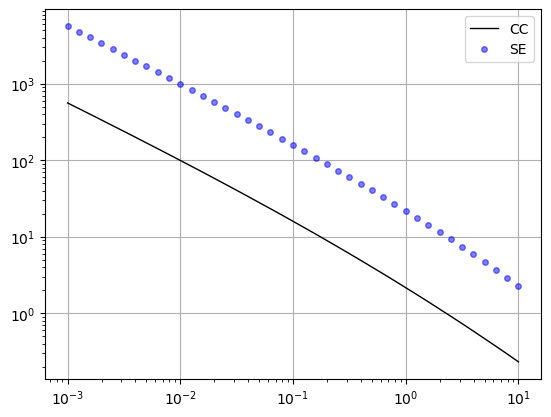

In [28]:
plt.loglog(t*1e3, obsSigma, 'k', lw=1, label='CC')
plt.loglog(t*1e3, predSigma, 'bo', alpha = 0.5, ms=4, label='SE')
plt.grid()
plt.legend()

In [22]:
MSE = np.mean((obsSigma-predSigma)**2)
print(MSE)

562.3618509860465
